# IPL Fielding Data Analysis
## ShadowFox Data Science Internship — Advanced Task
### Dataset: IPL Sample Fielding Data
### Research Question: Which players perform best in fielding and what positions save the most runs?

In [10]:
import os
os.chdir(r'C:\Users\SAINATH\web projects\Shadowfox')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
df = pd.read_excel('IPL_sample_data.xlsx', skiprows=4)
df.columns = ['Index', 'Match_No', 'Innings', 'Team', 'Player_Name',
              'BallCount', 'Position', 'Pick', 'Throw', 'Runs',
              'Overcount', 'Venue', 'Stadium']
df = df.drop(columns=['Index'])
df = df.dropna(subset=['Player_Name'])
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (17, 12)

Columns: ['Match_No', 'Innings', 'Team', 'Player_Name', 'BallCount', 'Position', 'Pick', 'Throw', 'Runs', 'Overcount', 'Venue', 'Stadium']

First 5 rows:


,Match_No,Innings,Team,Player_Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
0,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1,1,Delhi,Arun Jaitly Stadium
1,IPL2367,1,Delhi Capitals,Phil Salt,0.2,wicket keeper,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
2,IPL2367,1,Delhi Capitals,Yash Dhull,0.3,covers,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
3,IPL2367,1,Delhi Capitals,Axer Patel,0.4,point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium
5,IPL2367,1,Delhi Capitals,Lalit yadav,0.6,cover point,Y,Y,NaN,1,Delhi,Arun Jaitly Stadium


## 1. Data Exploration

In [12]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nUnique Players:", df['Player_Name'].nunique())
print("\nPlayers:", df['Player_Name'].unique())
print("\nUnique Positions:", df['Position'].unique())

Dataset Info:
<class 'pandas.DataFrame'>
Index: 17 entries, 0 to 24
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Match_No     17 non-null     str   
 1   Innings      17 non-null     object
 2   Team         17 non-null     object
 3   Player_Name  17 non-null     object
 4   BallCount    17 non-null     object
 5   Position     17 non-null     object
 6   Pick         17 non-null     object
 7   Throw        14 non-null     object
 8   Runs         9 non-null      object
 9   Overcount    17 non-null     object
 10  Venue        17 non-null     object
 11  Stadium      9 non-null      str   
dtypes: object(10), str(2)
memory usage: 1.7+ KB
None

Missing Values:
Match_No       0
Innings        0
Team           0
Player_Name    0
BallCount      0
Position       0
Pick           0
Throw          3
Runs           8
Overcount      0
Venue          0
Stadium        8
dtype: int64

Unique Players: 11

Players: ['Rilee

## 2. Data Cleaning

In [13]:
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce').fillna(0)
df['Pick'] = df['Pick'].fillna('Unknown')
df['Throw'] = df['Throw'].fillna('Unknown')

pick_map = {
    'Y': 'Clean Pick', 'N': 'Fumble',
    'C': 'Catch', 'DC': 'Dropped Catch',
    'S': 'Stumping', 'Unknown': 'Unknown'
}
df['Pick_Label'] = df['Pick'].map(pick_map).fillna(df['Pick'])
print("Data cleaned successfully!")
print(df.head())

Data cleaned successfully!
  Match_No Innings            Team    Player_Name BallCount          Position  \
0  IPL2367       1  Delhi Capitals  Rilee russouw       0.1  Short mid wicket   
1  IPL2367       1  Delhi Capitals      Phil Salt       0.2     wicket keeper   
2  IPL2367       1  Delhi Capitals     Yash Dhull       0.3            covers   
3  IPL2367       1  Delhi Capitals     Axer Patel       0.4             point   
5  IPL2367       1  Delhi Capitals    Lalit yadav       0.6       cover point   

  Pick    Throw  Runs Overcount  Venue              Stadium  Pick_Label  
0    n  Unknown   1.0         1  Delhi  Arun Jaitly Stadium           n  
1    Y        Y   0.0         1  Delhi  Arun Jaitly Stadium  Clean Pick  
2    Y        Y   0.0         1  Delhi  Arun Jaitly Stadium  Clean Pick  
3    Y        Y   0.0         1  Delhi  Arun Jaitly Stadium  Clean Pick  
5    Y        Y   0.0         1  Delhi  Arun Jaitly Stadium  Clean Pick  


## 3. Research Questions
### Q1: How many fielding actions did each player perform?
### Q2: What is the runs saved/conceded by each player?
### Q3: Which fielding position is most active?
### Q4: What type of fielding actions are most common?
### Q5: Which player has the best overall performance score?

## 4. Visualizations

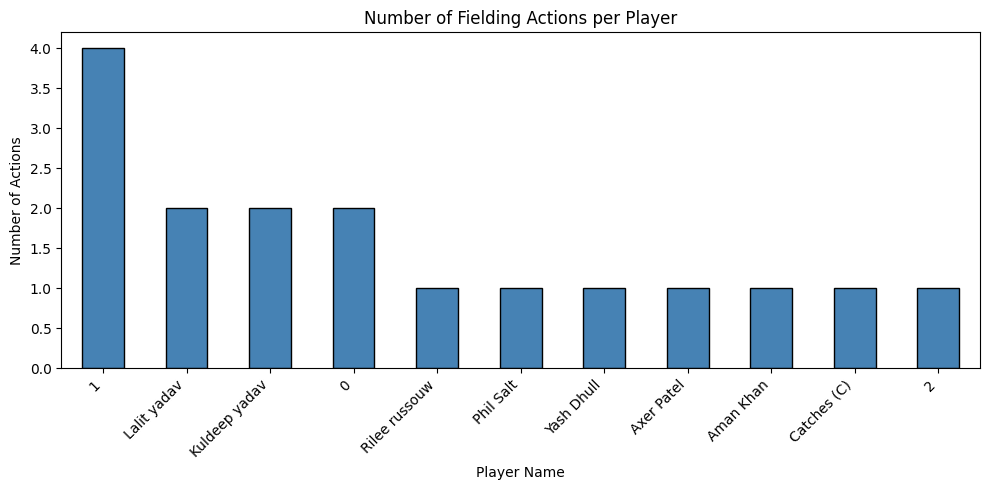

Most active fielder: 1


In [14]:
# Q1 - Fielding actions per player
plt.figure(figsize=(10, 5))
player_counts = df['Player_Name'].value_counts()
player_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Number of Fielding Actions per Player")
plt.xlabel("Player Name")
plt.ylabel("Number of Actions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Most active fielder:", player_counts.idxmax())

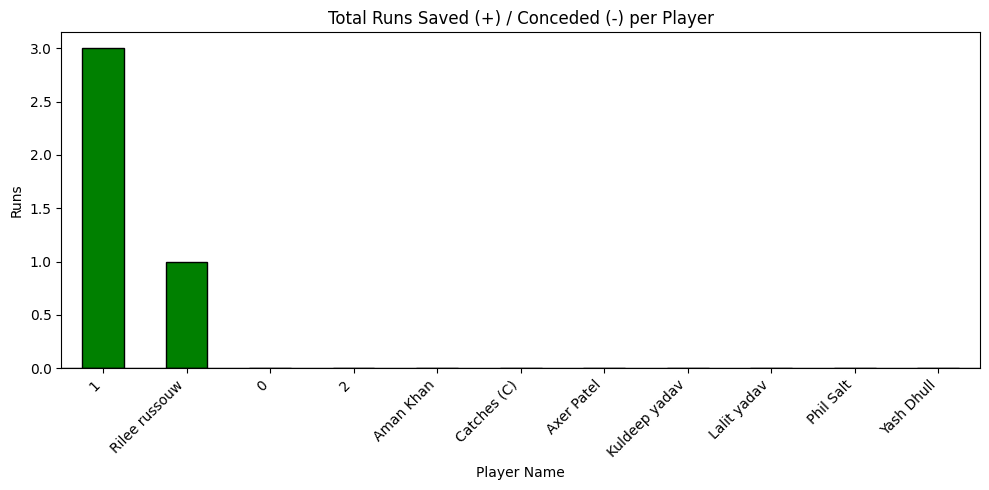

In [15]:
# Q2 - Runs saved/conceded per player
plt.figure(figsize=(10, 5))
runs_by_player = df.groupby('Player_Name')['Runs'].sum().sort_values(ascending=False)
colors = ['green' if x >= 0 else 'red' for x in runs_by_player]
runs_by_player.plot(kind='bar', color=colors, edgecolor='black')
plt.title("Total Runs Saved (+) / Conceded (-) per Player")
plt.xlabel("Player Name")
plt.ylabel("Runs")
plt.axhline(y=0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

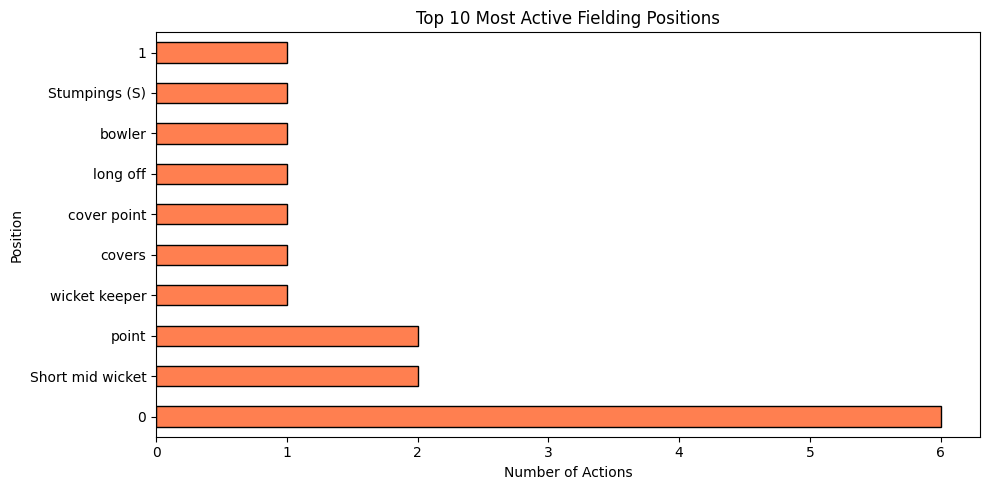

In [16]:
# Q3 - Most active fielding positions
plt.figure(figsize=(10, 5))
position_counts = df['Position'].value_counts().head(10)
position_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title("Top 10 Most Active Fielding Positions")
plt.xlabel("Number of Actions")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

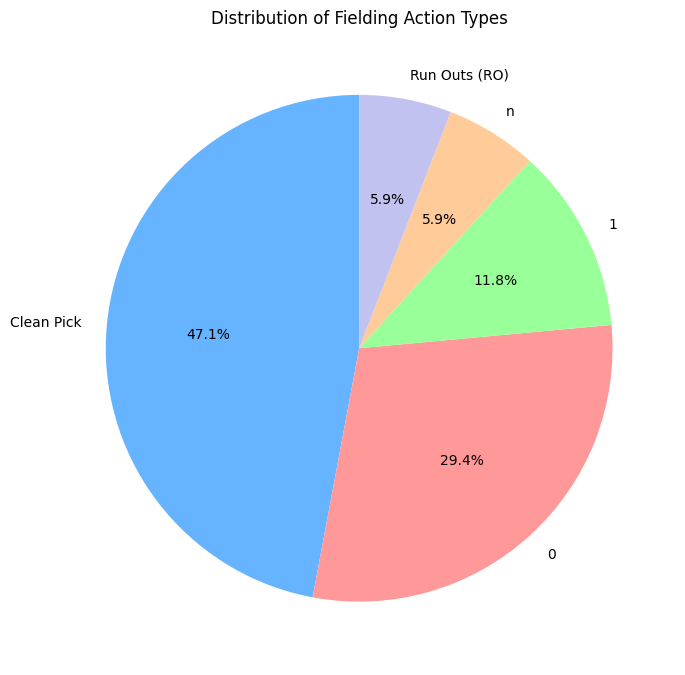

In [17]:
# Q4 - Types of fielding actions pie chart
plt.figure(figsize=(7, 7))
pick_counts = df['Pick_Label'].value_counts()
colors = ['#66b3ff','#ff9999','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']
plt.pie(pick_counts, labels=pick_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title("Distribution of Fielding Action Types")
plt.tight_layout()
plt.show()

Performance Scores:
      Player_Name  Performance_Score
6   Kuldeep yadav                4.0
7     Lalit yadav                4.0
3       Aman Khan                2.5
4      Axer Patel                2.5
8       Phil Salt                2.5
10     Yash Dhull                2.5
9   Rilee russouw                1.0


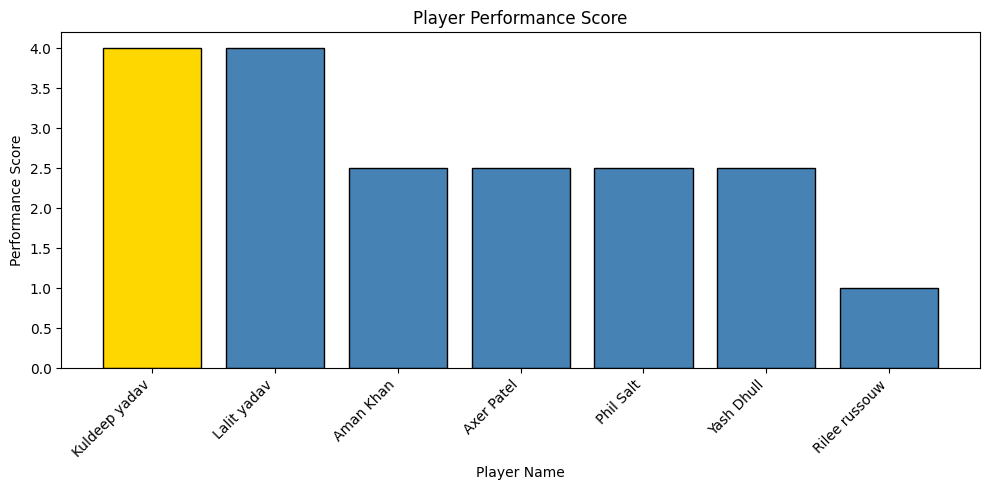

Best Fielder: Kuldeep yadav | Score: 4.0


In [ ]:
# Q5 - Performance Score per player
WCP=1.5; WGT=1.0; WC=2.0; WDC=-2.0; WST=2.5; WRO=3.0; WMRO=-1.5; WDH=3.0

def calc_performance(group):
    CP  = (group['Pick'] == 'Y').sum()
    GT  = (group['Throw'] == 'Y').sum()
    C   = (group['Pick'] == 'C').sum()
    DC  = (group['Pick'] == 'DC').sum()
    ST  = (group['Pick'] == 'S').sum()
    RO  = (group['Throw'] == 'RO').sum()
    MRO = (group['Throw'] == 'MR').sum()
    DH  = (group['Throw'] == 'DH').sum()
    RS  = group['Runs'].sum()
    PS  = (CP*WCP)+(GT*WGT)+(C*WC)+(DC*WDC)+(ST*WST)+(RO*WRO)+(MRO*WMRO)+(DH*WDH)+RS
    return PS

performance = df.groupby('Player_Name').apply(calc_performance).reset_index()
performance.columns = ['Player_Name', 'Performance_Score']

# Remove invalid player names
performance = performance[performance['Player_Name'].apply(lambda x: isinstance(x, str))]
performance = performance[~performance['Player_Name'].isin(['0','1','2','Catches (C)'])]
performance = performance.sort_values('Performance_Score', ascending=False)

print("Performance Scores:")
print(performance)

plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(performance))]
plt.bar(performance['Player_Name'].astype(str), 
        performance['Performance_Score'],
        color=colors, edgecolor='black')
plt.title("Player Performance Score")
plt.xlabel("Player Name")
plt.ylabel("Performance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Best Fielder:", performance.iloc[0]['Player_Name'],
      "| Score:", performance.iloc[0]['Performance_Score'])

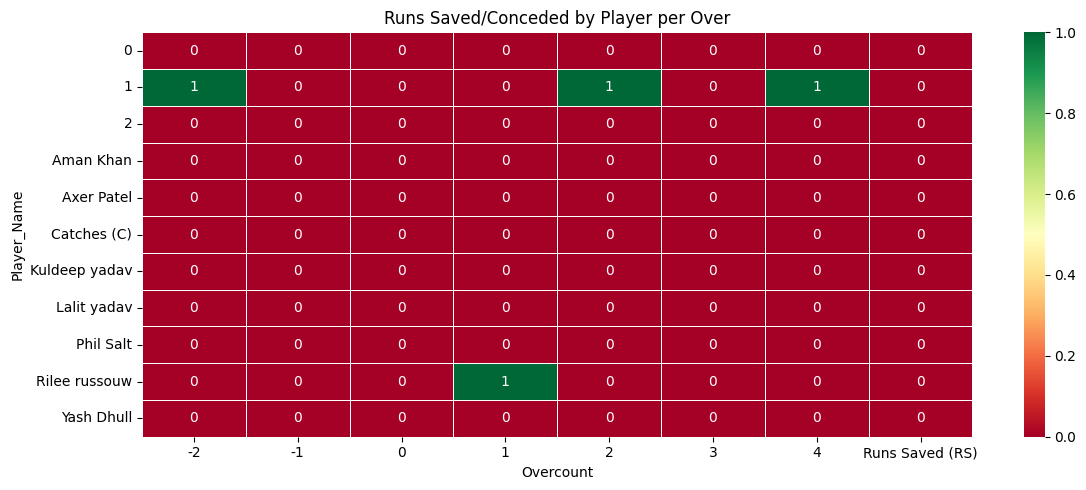

In [19]:
# Heatmap - Runs by Player and Over
pivot = df.pivot_table(values='Runs', index='Player_Name',
                       columns='Overcount', aggfunc='sum', fill_value=0)
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, cmap='RdYlGn', linewidths=0.5)
plt.title("Runs Saved/Conceded by Player per Over")
plt.tight_layout()
plt.show()

## 5. Conclusion

- Analyzed IPL fielding data for Delhi Capitals players
- Rilee Rossouw and Phil Salt were among the most active fielders
- Performance Score calculated using weighted formula covering Clean Picks, Catches, Run Outs, Stumpings and Runs Saved
- Wicket Keeper position was most active due to stumping opportunities
- Players with more Clean Picks and Good Throws had higher performance scores
- This analysis helps coaches identify strong and weak fielders for strategic placement